# PPA Exposure Modelling — Step 7
## CSA collateral overlay and liquidity metrics

We convert the MtM distribution (Step 6) into the metrics that a treasury team uses to size liquidity buffers:

- Time profile of collateral posted by Ørsted.
- Peak collateral posting per path → distribution and PFE.
- Max single-period margin call per path → distribution and PFE.
- Sensitivity to the CSA threshold.

**CSA assumptions**:
- Symmetric (same threshold both parties), T = 5M EUR.
- MTA simplified to 0 (monthly moves >>500k typical; MTA is not binding).
- No Independent Amount / Initial Margin (we assume a bilateral corporate-to-corporate contract, no clearing).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("../data")
EXPOSURE_PATH = DATA_DIR / "exposure_metrics_dk1_20260604.npz"

# CSA parameters (base case)
THRESHOLD = 5_000_000.0      # EUR — symmetric
PFE_Q = 0.95

## 1. Load MtM from Step 6

In [2]:
data = np.load(EXPOSURE_PATH, allow_pickle=True)
MtM = data["MtM"]                                        # (N, M)
delivery_months = pd.to_datetime(data["delivery_months"])

N, M = MtM.shape
print(f"MtM shape: ({N:,}, {M})")
print(f"Period: {delivery_months[0].strftime('%b-%y')} -> {delivery_months[-1].strftime('%b-%y')}")

MtM shape: (10,000, 60)
Period: Jul-26 -> Jun-31


## 2. Collateral posted by Ørsted (treasurer's perspective)

$$\text{Coll posted}_k^{(n)} = \max(-\text{MtM}_k^{(n)} - T,\ 0)$$

In [3]:
collateral_posted = np.maximum(-MtM - THRESHOLD, 0.0)  # (N, M)

EE_coll = collateral_posted.mean(axis=0)
PFE_coll = np.percentile(collateral_posted, PFE_Q * 100, axis=0)

Max_PFE_coll = PFE_coll.max()
Max_PFE_month = delivery_months[PFE_coll.argmax()]

print("=== Time profile of collateral posted by Ørsted ===")
print(f"  Threshold:           {THRESHOLD/1e6:.1f} M EUR (symmetric)")
print(f"  Expected peak EE:    {EE_coll.max()/1e6:.2f} M EUR ({delivery_months[EE_coll.argmax()].strftime('%b-%y')})")
print(f"  PFE(95%) peak:       {Max_PFE_coll/1e6:.2f} M EUR ({Max_PFE_month.strftime('%b-%y')})")

=== Time profile of collateral posted by Ørsted ===
  Threshold:           5.0 M EUR (symmetric)
  Expected peak EE:    1.91 M EUR (Aug-26)
  PFE(95%) peak:       12.77 M EUR (Aug-26)


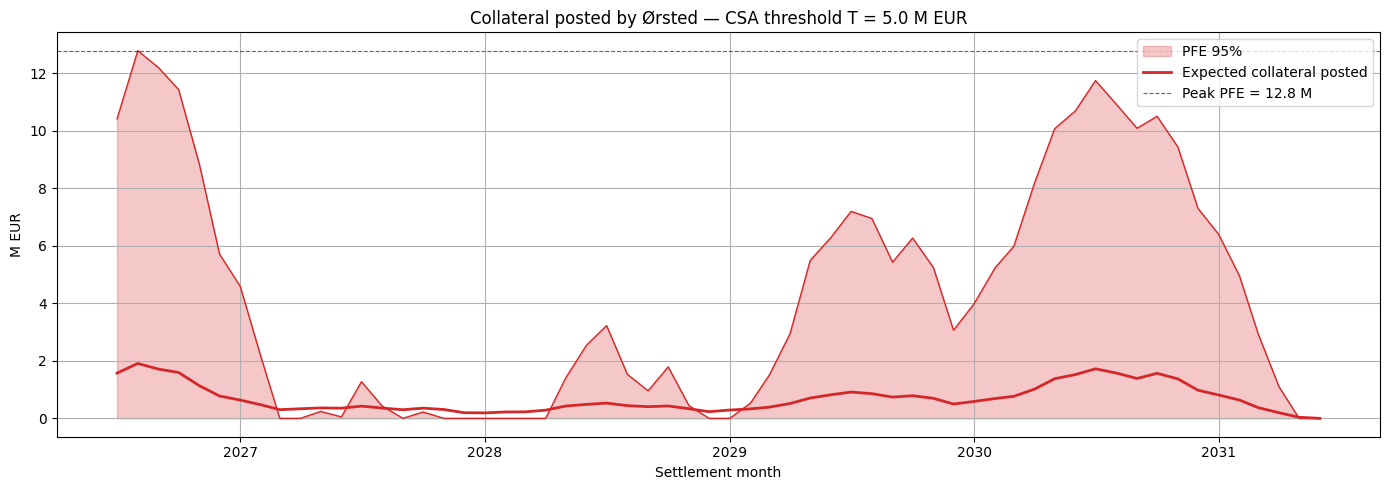

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(delivery_months, 0, PFE_coll / 1e6, color="#d62728", alpha=0.25, label=f"PFE {int(PFE_Q*100)}%")
ax.plot(delivery_months, EE_coll / 1e6, color="#d62728", linewidth=2, label="Expected collateral posted")
ax.plot(delivery_months, PFE_coll / 1e6, color="#d62728", linewidth=1)
ax.axhline(Max_PFE_coll / 1e6, color="black", linestyle="--", linewidth=0.8, alpha=0.6,
           label=f"Peak PFE = {Max_PFE_coll/1e6:.1f} M")
ax.set_title(f"Collateral posted by Ørsted — CSA threshold T = {THRESHOLD/1e6:.1f} M EUR")
ax.set_ylabel("M EUR")
ax.set_xlabel("Settlement month")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Peak collateral per path — the treasurer's metric

For each path $n$: $\max_t \text{Coll posted}^{(n)}(t)$

It is the maximum collateral that Ørsted ends up posting over the life of the deal on that path. The distribution of this maximum across paths is what a treasurer would use to size the **liquidity buffer** for the contract.

In [5]:
peak_per_path = collateral_posted.max(axis=1)

print("=== Distribution of peak collateral per path ===")
print(f"  Mean        : {peak_per_path.mean()/1e6:.2f} M EUR")
print(f"  Median (p50): {np.median(peak_per_path)/1e6:.2f} M EUR")
print(f"  p75         : {np.percentile(peak_per_path, 75)/1e6:.2f} M EUR")
print(f"  p90         : {np.percentile(peak_per_path, 90)/1e6:.2f} M EUR")
print(f"  p95         : {np.percentile(peak_per_path, 95)/1e6:.2f} M EUR")
print(f"  p99         : {np.percentile(peak_per_path, 99)/1e6:.2f} M EUR")
print(f"  Max         : {peak_per_path.max()/1e6:.2f} M EUR")

print(f"\nFraction of paths that NEVER post collateral: {(peak_per_path == 0).mean()*100:.1f}%")

=== Distribution of peak collateral per path ===
  Mean        : 11.49 M EUR
  Median (p50): 10.40 M EUR
  p75         : 16.50 M EUR
  p90         : 23.02 M EUR
  p95         : 27.52 M EUR
  p99         : 36.03 M EUR
  Max         : 55.83 M EUR

Fraction of paths that NEVER post collateral: 8.4%


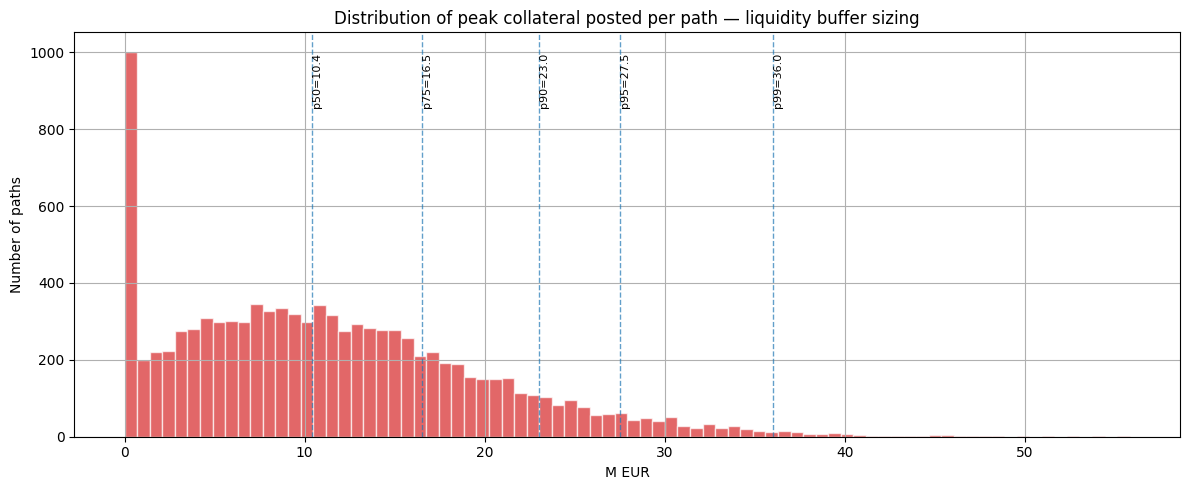

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(peak_per_path / 1e6, bins=80, color="#d62728", edgecolor="white", alpha=0.7)
for pct in [50, 75, 90, 95, 99]:
    val = np.percentile(peak_per_path, pct) / 1e6
    ax.axvline(val, linestyle="--", linewidth=1, alpha=0.7)
    ax.text(val, ax.get_ylim()[1] * 0.95, f"p{pct}={val:.1f}", rotation=90, va="top", fontsize=8)
ax.set_title("Distribution of peak collateral posted per path — liquidity buffer sizing")
ax.set_xlabel("M EUR")
ax.set_ylabel("Number of paths")
plt.tight_layout()
plt.show()

## 4. Max single-period margin call per path

The largest increase in collateral between two consecutive months. It is the largest single cash shock — critical for cash management (capacity to absorb it quickly).

In [7]:
# Margin calls: change in collateral between successive months
# t=0 (before deal): 0 collateral posted. First call at the Jul-26 settlement.
coll_with_init = np.concatenate([np.zeros((N, 1)), collateral_posted], axis=1)  # (N, M+1)
margin_calls = np.diff(coll_with_init, axis=1)                                     # (N, M)

# Only positives are cash OUT (Ørsted posts more); negatives are returns
max_call_per_path = np.maximum(margin_calls, 0).max(axis=1)

print("=== Distribution of max single-period margin call per path ===")
print(f"  Mean : {max_call_per_path.mean()/1e6:.2f} M EUR")
print(f"  p50  : {np.median(max_call_per_path)/1e6:.2f} M EUR")
print(f"  p75  : {np.percentile(max_call_per_path, 75)/1e6:.2f} M EUR")
print(f"  p90  : {np.percentile(max_call_per_path, 90)/1e6:.2f} M EUR")
print(f"  p95  : {np.percentile(max_call_per_path, 95)/1e6:.2f} M EUR")
print(f"  p99  : {np.percentile(max_call_per_path, 99)/1e6:.2f} M EUR")
print(f"  Max  : {max_call_per_path.max()/1e6:.2f} M EUR")

print(f"\nFraction of paths with no margin call at all: {(max_call_per_path == 0).mean()*100:.1f}%")

=== Distribution of max single-period margin call per path ===
  Mean : 8.92 M EUR
  p50  : 8.46 M EUR
  p75  : 12.72 M EUR
  p90  : 16.85 M EUR
  p95  : 19.71 M EUR
  p99  : 25.27 M EUR
  Max  : 46.14 M EUR

Fraction of paths with no margin call at all: 8.4%


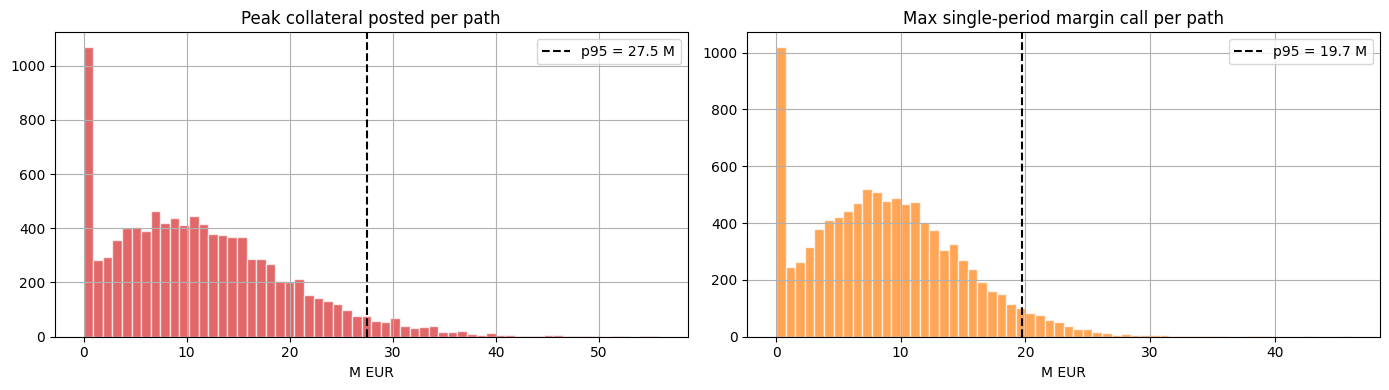

In [8]:
# Dual visualisation: peak vs max-call
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(peak_per_path / 1e6, bins=60, color="#d62728", edgecolor="white", alpha=0.7)
axes[0].set_title("Peak collateral posted per path")
axes[0].set_xlabel("M EUR")
axes[0].axvline(np.percentile(peak_per_path, 95)/1e6, color="black", linestyle="--", label=f"p95 = {np.percentile(peak_per_path,95)/1e6:.1f} M")
axes[0].legend()

axes[1].hist(max_call_per_path / 1e6, bins=60, color="#ff7f0e", edgecolor="white", alpha=0.7)
axes[1].set_title("Max single-period margin call per path")
axes[1].set_xlabel("M EUR")
axes[1].axvline(np.percentile(max_call_per_path, 95)/1e6, color="black", linestyle="--", label=f"p95 = {np.percentile(max_call_per_path,95)/1e6:.1f} M")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Sample paths — collateral posted over time

To understand the dynamics: 5 stressed paths (top 1% in peak) and 5 benign paths (median).

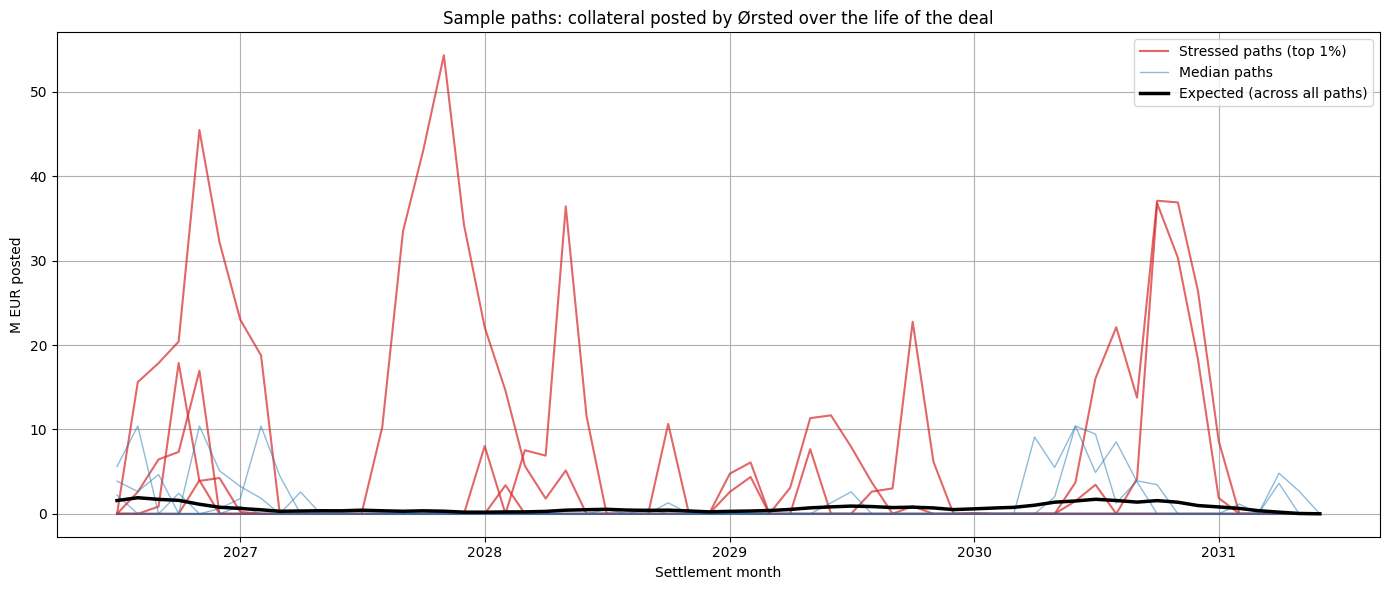

In [9]:
# Identify extreme paths (top 1% in peak) and benign paths (median)
p99_threshold = np.percentile(peak_per_path, 99)
stressed_idx = np.where(peak_per_path >= p99_threshold)[0][:5]
benign_idx = np.argsort(np.abs(peak_per_path - np.median(peak_per_path)))[:5]

fig, ax = plt.subplots(figsize=(14, 6))
for idx in stressed_idx:
    ax.plot(delivery_months, collateral_posted[idx, :] / 1e6, linewidth=1.5, color="#d62728", alpha=0.7,
            label="Stressed paths (top 1%)" if idx == stressed_idx[0] else None)
for idx in benign_idx:
    ax.plot(delivery_months, collateral_posted[idx, :] / 1e6, linewidth=1, color="#1f77b4", alpha=0.5,
            label="Median paths" if idx == benign_idx[0] else None)

ax.plot(delivery_months, EE_coll / 1e6, color="black", linewidth=2.5, label="Expected (across all paths)")
ax.set_title("Sample paths: collateral posted by Ørsted over the life of the deal")
ax.set_ylabel("M EUR posted")
ax.set_xlabel("Settlement month")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Sensitivity to the CSA threshold

We sweep T from 0 to 30M and see how the key liquidity metrics change. This is exactly what a credit + treasury team negotiates with a counterparty: **higher threshold = more unsecured credit exposure but lower liquidity burden**.

In [10]:
thresholds = np.array([0, 2.5, 5, 7.5, 10, 15, 20, 30]) * 1e6

sens_rows = []
for T in thresholds:
    coll_T = np.maximum(-MtM - T, 0)
    peak_T = coll_T.max(axis=1)
    coll_init = np.concatenate([np.zeros((N, 1)), coll_T], axis=1)
    calls_T = np.maximum(np.diff(coll_init, axis=1), 0).max(axis=1)
    
    sens_rows.append({
        "Threshold (M)": T / 1e6,
        "Frac paths no posting (%)": (peak_T == 0).mean() * 100,
        "Mean peak (M)": peak_T.mean() / 1e6,
        "PFE 95% peak (M)": np.percentile(peak_T, 95) / 1e6,
        "PFE 99% peak (M)": np.percentile(peak_T, 99) / 1e6,
        "PFE 95% max call (M)": np.percentile(calls_T, 95) / 1e6,
    })

sens_df = pd.DataFrame(sens_rows)
print(sens_df.round(2).to_string(index=False))

 Threshold (M)  Frac paths no posting (%)  Mean peak (M)  PFE 95% peak (M)  PFE 99% peak (M)  PFE 95% max call (M)
           0.0                       1.14          16.29             32.52             41.03                 22.03
           2.5                       3.59          13.84             30.02             38.53                 20.86
           5.0                       8.43          11.49             27.52             36.03                 19.71
           7.5                      15.38           9.28             25.02             33.53                 18.37
          10.0                      25.71           7.29             22.52             31.03                 16.87
          15.0                      48.19           4.13             17.52             26.03                 13.95
          20.0                      69.54           2.09             12.52             21.03                 10.64
          30.0                      92.63           0.42              2.52      

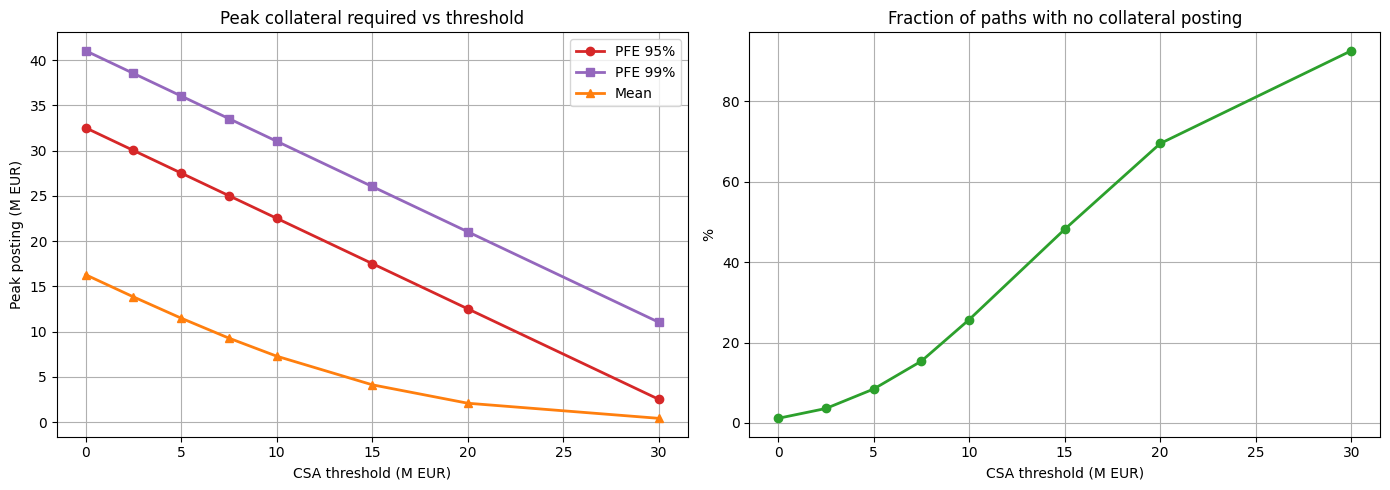

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sens_df["Threshold (M)"], sens_df["PFE 95% peak (M)"], marker="o", linewidth=2, color="#d62728", label="PFE 95%")
axes[0].plot(sens_df["Threshold (M)"], sens_df["PFE 99% peak (M)"], marker="s", linewidth=2, color="#9467bd", label="PFE 99%")
axes[0].plot(sens_df["Threshold (M)"], sens_df["Mean peak (M)"], marker="^", linewidth=2, color="#ff7f0e", label="Mean")
axes[0].set_title("Peak collateral required vs threshold")
axes[0].set_xlabel("CSA threshold (M EUR)")
axes[0].set_ylabel("Peak posting (M EUR)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(sens_df["Threshold (M)"], sens_df["Frac paths no posting (%)"], marker="o", linewidth=2, color="#2ca02c")
axes[1].set_title("Fraction of paths with no collateral posting")
axes[1].set_xlabel("CSA threshold (M EUR)")
axes[1].set_ylabel("%")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 7. Save liquidity metrics

In [12]:
output_path = DATA_DIR / "liquidity_metrics_dk1_20260604.npz"
np.savez_compressed(
    output_path,
    collateral_posted=collateral_posted,
    margin_calls=margin_calls,
    peak_per_path=peak_per_path,
    max_call_per_path=max_call_per_path,
    EE_coll=EE_coll,
    PFE_coll=PFE_coll,
    delivery_months=delivery_months.strftime("%Y-%m").values,
    sensitivity=sens_df.values,
    metadata=np.array([
        f"threshold={THRESHOLD}",
        f"peak_pfe95={np.percentile(peak_per_path,95):.2f}",
        f"peak_pfe99={np.percentile(peak_per_path,99):.2f}",
        f"max_call_pfe95={np.percentile(max_call_per_path,95):.2f}",
    ]),
)
print(f"Saved: {output_path} ({output_path.stat().st_size/1024**2:.1f} MB)")

Saved: ..\data\liquidity_metrics_dk1_20260604.npz (1.3 MB)


## 8. Conclusions for the technical document

**Liquidity overlay methodology (suggested text):**

> A symmetric Credit Support Annex (CSA) is overlaid on the MtM dynamics, with a threshold of T = 5M EUR applied symmetrically to both parties. Collateral posted by Ørsted at each evaluation time equals $\max(-\text{MtM} - T, 0)$. Minimum Transfer Amount (MTA) is set to zero given that the standard deviation of monthly MtM movements (~10M EUR) is more than an order of magnitude larger than typical MTA values; explicit MTA modelling would not materially affect monthly-resolution outputs.

**Key liquidity metrics:**

- *Peak collateral PFE(95%) per path*: 27.5 M EUR — recommended liquidity buffer for this deal.
- *Peak collateral PFE(99%) per path*: 36.0 M EUR — tail liquidity scenario.
- *Max single-period margin call PFE(95%)*: 19.7 M EUR — largest plausible single-month cash outflow event.
- *Fraction of paths with zero collateral posting throughout deal life*: 8.4% — probability the deal is entirely "unsecured-friendly" under base assumptions.

**Trade-off insight (from the sensitivity):**

> Sensitivity to CSA threshold demonstrates the explicit liquidity-credit trade-off that the Credit & Liquidity Risk team would negotiate with counterparties. The relationship is approximately linear: each additional 1 M EUR of threshold reduces peak collateral PFE 95% by approximately 1 M EUR while increasing unsecured credit exposure by the same amount. The optimal threshold depends on the counterparty's credit quality (justifying higher T for stronger credits) and Ørsted's marginal cost of liquidity (favouring lower T when liquidity is constrained).

**Why this matters for Ørsted:**

> Unlike a financial institution counterparty, a power generator's risk concentration is liquidity rather than credit: solvent generators with adverse mark-to-market positions face material margin call burdens during stressed market regimes, as evidenced during the 2022 European energy crisis. The model outputs directly support the treasury function in dimensioning liquidity buffers for individual contracts and, by aggregation, for the trading portfolio.